In [5]:
# Cell 4 — Install thermal plugins
import subprocess
subprocess.run(["pip", "install", "pyroll-integral-thermal", "--break-system-packages", "-q"])

CompletedProcess(args=['pip', 'install', 'pyroll-integral-thermal', '--break-system-packages', '-q'], returncode=0)

In [6]:
# Cell 1 — Updated imports
import pyroll.core as pr
import pyroll.wusatowski_spreading
import pyroll.integral_thermal        # ← thermal model for transports
import matplotlib.pyplot as plt
import numpy as np

print("Imports ✓")
from importlib.metadata import version
print("PyRolL version:", version("pyroll-core"))

Imports ✓
PyRolL version: 3.1.1


In [7]:
in_profile = pr.Profile.round(
    radius=30e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["steel", "C15"],
    flow_stress=100e6,
    density=7.5e3,
    specific_heat_capacity=690,
    thermal_conductivity=23,
    environment_temperature=20 + 273.15,  # ← add this
)
print("Incoming profile:")
print(f"  Diameter:          {in_profile.radius*2000:.1f} mm")
print(f"  Temperature:       {in_profile.temperature - 273.15:.0f} °C")
print(f"  Thermal conduct.:  {in_profile.thermal_conductivity} W/m·K")
print(f"  Specific heat:     {in_profile.specific_heat_capacity} J/kg·K")
print(f"  Density:           {in_profile.density} kg/m³")

Incoming profile:
  Diameter:          60.0 mm
  Temperature:       1200 °C
  Thermal conduct.:  23 W/m·K
  Specific heat:     690 J/kg·K
  Density:           7500.0 kg/m³


In [9]:
in_profile = pr.Profile.round(
    radius=30e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["steel", "C15"],
    flow_stress=100e6,
    density=7.5e3,
    specific_heat_capacity=690,
    thermal_conductivity=23,
    environment_temperature=20 + 273.15,
    surface_heat_transfer_coefficient=100,  # ← add this W/m²·K
)

sequence = pr.PassSequence([
    pr.RollPass(
        label="R1 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=2e-3, r2=50e-3, depth=10e-3),
            nominal_radius=155e-3,
            rotational_frequency=1,
            temperature=20 + 273.15,
        ),
        gap=8e-3,
    ),
    pr.Transport(
        label="R1->R2",
        duration=2,              # ← 2 seconds between passes
        environment_temperature=20 + 273.15,  # ← add this
        surface_heat_transfer_coefficient=10, # ← add this
    ),
    pr.RollPass(
        label="R2 - Round",
        roll=pr.Roll(
            groove=pr.FalseRoundGroove(r1=2e-3, r2=25e-3, depth=12e-3, flank_angle=30),
            nominal_radius=155e-3,
            rotational_frequency=1,
            temperature=20 + 273.15,
        ),
        gap=12e-3,
    ),
    pr.Transport(
        label="R2->R3",
        duration=2,
        environment_temperature=20 + 273.15,
        surface_heat_transfer_coefficient=10,
    ),
    pr.RollPass(
        label="R3 - Oval",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(r1=2e-3, r2=30e-3, depth=6e-3),
            nominal_radius=155e-3,
            rotational_frequency=1,
            temperature=20 + 273.15,
        ),
        gap=10e-3,
    ),
    pr.Transport(
        label="R3->R4",
        duration=2,
        environment_temperature=20 + 273.15,
        surface_heat_transfer_coefficient=10,
    ),
    pr.RollPass(
        label="R4 - Round",
        roll=pr.Roll(
            groove=pr.RoundGroove(r1=1e-3, r2=35e-3, depth=4e-3),
            nominal_radius=155e-3,
            rotational_frequency=1,
            temperature=20 + 273.15,
        ),
        gap=10e-3,
    ),
])

sequence.solve(in_profile)
print("Solved ✓")

Solved ✓


In [10]:
# Extract temperature evolution through entire sequence
labels = []
temperatures = []

# Add incoming profile
labels.append("Incoming")
temperatures.append(in_profile.temperature - 273.15)

# Extract from each unit
for unit in sequence:
    if isinstance(unit, pr.RollPass):
        labels.append(unit.label)
        temperatures.append(unit.out_profile.temperature - 273.15)
    elif isinstance(unit, pr.Transport):
        labels.append(unit.label)
        temperatures.append(unit.out_profile.temperature - 273.15)

print("Temperature evolution:")
print("="*45)
for label, temp in zip(labels, temperatures):
    bar = "█" * int(temp / 30)
    print(f"{label:<15} {temp:>8.1f} °C  {bar}")
print("="*45)
print(f"Total temperature drop: {temperatures[0] - temperatures[-1]:.1f} °C")

Temperature evolution:
Incoming          1200.0 °C  ████████████████████████████████████████
R1 - Oval         1209.5 °C  ████████████████████████████████████████
R1->R2            1198.5 °C  ███████████████████████████████████████
R2 - Round        1205.2 °C  ████████████████████████████████████████
R2->R3            1196.0 °C  ███████████████████████████████████████
R3 - Oval         1202.4 °C  ████████████████████████████████████████
R3->R4            1188.7 °C  ███████████████████████████████████████
R4 - Round        1197.5 °C  ███████████████████████████████████████
Total temperature drop: 2.5 °C


In [11]:
# Cell 6 — Mechanical results
print("="*65)
print(f"{'Pass':<15} {'Force (MN)':>12} {'Strain':>10} {'Temp in°C':>12} {'Temp out°C':>12}")
print("="*65)

for unit in sequence:
    if isinstance(unit, pr.RollPass):
        try:
            force = unit.roll_force / 1e6
        except:
            force = float('nan')
        try:
            strain = unit.strain
        except:
            strain = float('nan')
        t_in  = unit.in_profile.temperature - 273.15
        t_out = unit.out_profile.temperature - 273.15
        print(f"{unit.label:<15} {force:>12.3f} {strain:>10.4f} {t_in:>12.1f} {t_out:>12.1f}")

print("="*65)

Pass              Force (MN)     Strain    Temp in°C   Temp out°C
R1 - Oval              0.445     0.8942       1200.0       1209.5
R2 - Round             0.251     0.6669       1198.5       1205.2
R3 - Oval              0.230     0.7294       1196.0       1202.4
R4 - Round             0.206     0.9732       1188.7       1197.5


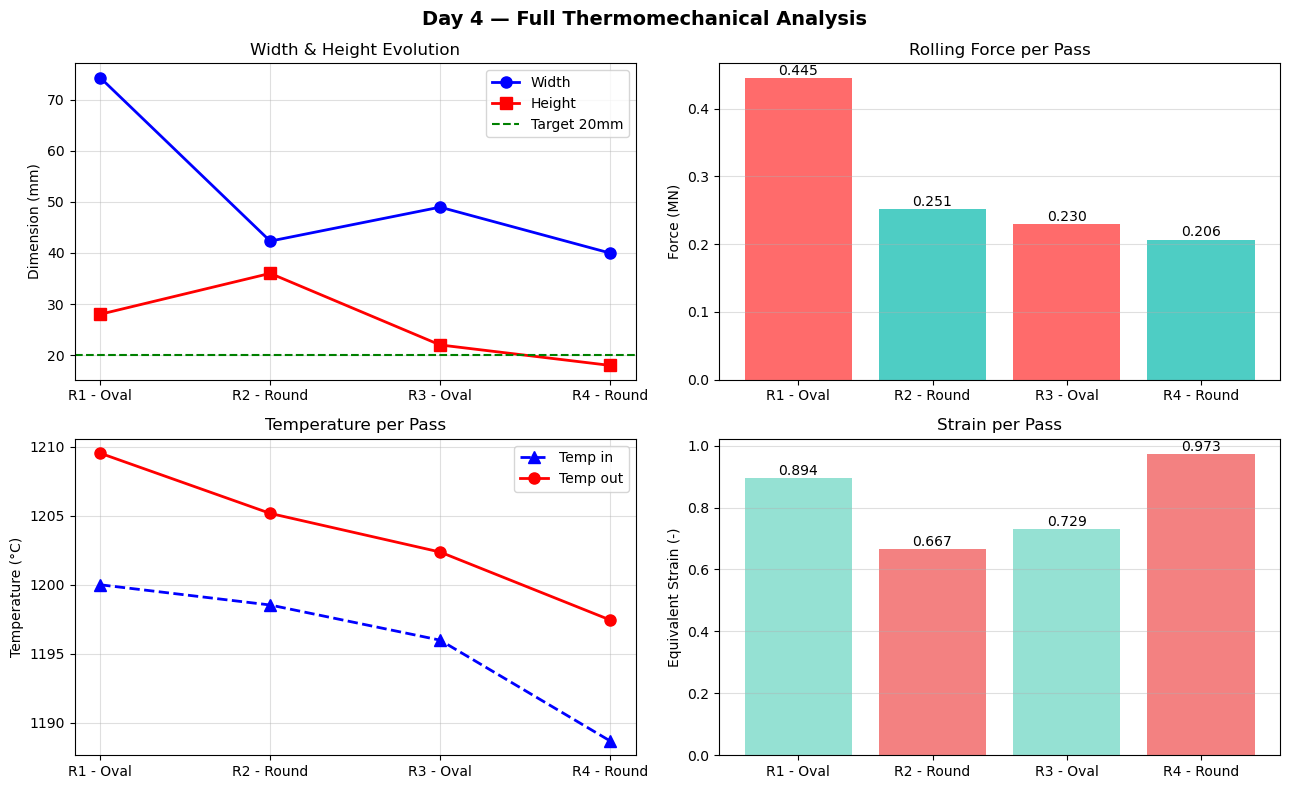

In [12]:
# Cell 7 — Full thermomechanical dashboard
passes = [u.label for u in sequence if isinstance(u, pr.RollPass)]
forces = [u.roll_force/1e6 for u in sequence if isinstance(u, pr.RollPass)]
strains = [u.strain for u in sequence if isinstance(u, pr.RollPass)]
t_in  = [u.in_profile.temperature-273.15 for u in sequence if isinstance(u, pr.RollPass)]
t_out = [u.out_profile.temperature-273.15 for u in sequence if isinstance(u, pr.RollPass)]
widths = [u.out_profile.width*1000 for u in sequence if isinstance(u, pr.RollPass)]
heights = [u.out_profile.height*1000 for u in sequence if isinstance(u, pr.RollPass)]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Plot 1 — Dimensions
axes[0,0].plot(passes, widths, 'bo-', linewidth=2, markersize=8, label='Width')
axes[0,0].plot(passes, heights, 'rs-', linewidth=2, markersize=8, label='Height')
axes[0,0].axhline(y=20, color='green', linestyle='--', label='Target 20mm')
axes[0,0].set_title('Width & Height Evolution')
axes[0,0].set_ylabel('Dimension (mm)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.4)

# Plot 2 — Rolling Force
axes[0,1].bar(passes, forces, color=['#FF6B6B','#4ECDC4','#FF6B6B','#4ECDC4'])
axes[0,1].set_title('Rolling Force per Pass')
axes[0,1].set_ylabel('Force (MN)')
axes[0,1].grid(True, alpha=0.4, axis='y')
for i, f in enumerate(forces):
    axes[0,1].text(i, f+0.005, f'{f:.3f}', ha='center', fontsize=10)

# Plot 3 — Temperature
axes[1,0].plot(passes, t_in, 'b^--', linewidth=2, markersize=8, label='Temp in')
axes[1,0].plot(passes, t_out, 'ro-', linewidth=2, markersize=8, label='Temp out')
axes[1,0].set_title('Temperature per Pass')
axes[1,0].set_ylabel('Temperature (°C)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.4)

# Plot 4 — Strain
axes[1,1].bar(passes, strains, color=['#95E1D3','#F38181','#95E1D3','#F38181'])
axes[1,1].set_title('Strain per Pass')
axes[1,1].set_ylabel('Equivalent Strain (-)')
axes[1,1].grid(True, alpha=0.4, axis='y')
for i, s in enumerate(strains):
    axes[1,1].text(i, s+0.01, f'{s:.3f}', ha='center', fontsize=10)

plt.suptitle('Day 4 — Full Thermomechanical Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('day04_dashboard.png', dpi=150)
plt.show()